This notebook is a tutorial for computing SEACell metacells, visualizing results and computing evaluation metrics

# Imports

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

In [ ]:
import SEACells

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100


# Load Data

We recommend the use of scanpy Anndata objects as the preferred mode of loading and filtering data.

A sample datset is available for download with the instructions listed below. This is a filtered, unnormalized counts of single-nuclear RNA-seq dataset of CD34+ sorted bone marrow cells to profile human hematopoiesis [Dataset ref TBD].

Uncomment the following lines to download the sample dataset in a Unix-based system. For non-UNIX systems, download the files using the URL

In [ ]:
data_dir = os.path.expanduser('ArchR_malignant_seacells/export/')

In [ ]:
# Load the data using 
adata = sc.read(os.path.join(data_dir, "archr_for_seacells.h5ad"))
adata

AnnData object with n_obs × n_vars = 83921 × 377577
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'Clusters', 'ReadsInPeaks', 'FRIP', 'MP', 'leiden'
    var: 'seqnames', 'start', 'end', 'width', 'strand', 'score', 'replicateScoreQuantile', 'groupScoreQuantile', 'Reproducibility', 'GroupReplicate', 'nearestGene', 'distToGeneStart', 'peakType', 'distToTSS', 'nearestTSS', 'GC', 'idx', 'N'
    uns: 'GeneScoresColums', 'MP_colors', 'leiden', 'leiden_colors', 'neighbors', 'umap'
    obsm: 'GeneScores', 'X_svd', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs

,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,nFrags,nDiFrags,BlacklistRatio,Clusters,ReadsInPeaks,FRIP,MP,leiden
x,,,,,,,,,,,,,,,,,,
multiome_P-6774_S-10146#CTCAGGATCTTGCTAT-1,multiome_P-6774_S-10146,1.948,2154,4422,1877,0.022375,1,1.363341,17719,41812,98816,39285,0.009497,C24,6854,0.081595,MP 5,11
multiome_P-6774_S-10146#GTAGCGCTCCACCCTG-1,multiome_P-6774_S-10146,1.479,2778,6735,2463,0.035092,1,0.712341,12519,56042,95963,27402,0.012833,C24,13316,0.118388,MP 5,2
multiome_P-6774_S-10146#GGCAATCGTCCTCCAA-1,multiome_P-6774_S-10146,2.202,2499,4807,2107,0.027021,1,1.356604,17115,37745,88950,34090,0.011844,C24,7168,0.094557,MP 2,2
multiome_P-6774_S-10146#CGGACCTAGGCCTAAT-1,multiome_P-6774_S-10146,2.146,3906,7690,1330,0.044967,1,1.099283,14671,40732,85508,30105,0.007777,C24,12262,0.149789,MP 5,2
multiome_P-6774_S-10146#CCACTTGGTTGCGGAT-1,multiome_P-6774_S-10146,1.548,1447,3414,2351,0.020204,1,1.052598,14368,41161,84487,28958,0.013913,C24,6055,0.073282,MP 2,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
atac_P-6255_S-8500#GAGTGAGTCGATGAAA-1,atac_P-6255_S-8500,9.256,2585,3256,312,0.116602,1,1.045714,2168,6825,13962,4969,0.011173,C24,4953,0.362167,MP 9,11
atac_P-6255_S-8500#GAGTGAGTCACGGGTC-1,atac_P-6255_S-8500,8.349,2264,2977,301,0.114509,1,1.098305,2133,6195,12999,4671,0.011578,C24,4575,0.368357,MP 9,11
atac_P-6255_S-8500#ACCTGCTAGGTCCTCG-1,atac_P-6255_S-8500,7.327,2220,2896,176,0.111651,1,1.750583,2332,4715,12969,5922,0.006785,C16,4072,0.430080,MP 2,11


In [ ]:
# Plot cell-types for reference
adata.obs['celltype'] = adata.obs['MP']

In [ ]:
emb = sc.read(os.path.join("malignant_embbeding.h5ad"))
emb

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/anndata-0.9.1-py3.9.egg/anndata/_core/anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 381770 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5'

In [ ]:
emb = emb[emb.obs['domain'].isin(['scATAC-seq'])]
emb

View of AnnData object with n_obs × n_vars = 90075 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louva

In [ ]:
import re

# Define the pattern and replacement
pattern = r"(.*)_(.*)$"
replacement = r"\1#\2"

# Apply the pattern and replacement using a lambda function with regex substitution
emb.obs.index = emb.obs.index.to_series().apply(lambda x: re.sub(pattern, replacement, x))

In [ ]:
emb.obs

,scDblFinder.class,scDblFinder.score,ID,SampleID,Batch_for_correction,Study,Institute,Preservation_method,Diagnosis,Tumor_type,...,louvain_1,louvain_1_3,louvain_1_5,louvain_1_8,louvain_2,louvain_2_3,louvain_2_5,louvain_2_8,louvain_3,iCNV
atac_T19-91014#AAACGAAAGACCCTAT-1,singlet,0.002427,T19-91014,T19-91014,10X_v1.1_nuclei_atac,Ruiz2023,PMC,Cryo,DMG Pons,DMG H3 K27-altered,...,10,16,18,19,18,26,18,27,21,Not measured
atac_T19-91014#AAACGAAAGTGTAATG-1,singlet,0.005396,T19-91014,T19-91014,10X_v1.1_nuclei_atac,Ruiz2023,PMC,Cryo,DMG Pons,DMG H3 K27-altered,...,10,16,18,19,18,26,18,27,21,Not measured
atac_T19-91014#AAACGAACAAATGCTC-1,singlet,0.011626,T19-91014,T19-91014,10X_v1.1_nuclei_atac,Ruiz2023,PMC,Cryo,DMG Pons,DMG H3 K27-altered,...,2,1,1,20,16,33,15,34,33,Not measured
atac_T19-91014#AAACGAACACGCCGAT-1,singlet,0.003790,T19-91014,T19-91014,10X_v1.1_nuclei_atac,Ruiz2023,PMC,Cryo,DMG Pons,DMG H3 K27-altered,...,10,16,18,19,18,26,18,27,21,Not measured
atac_T19-91014#AAACGAAGTACGGAGT-1,doublet,0.992360,T19-91014,T19-91014,10X_v1.1_nuclei_atac,Ruiz2023,PMC,Cryo,DMG Pons,DMG H3 K27-altered,...,10,16,18,19,18,26,18,27,21,Not measured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
multiome_P-6774_S-10146#TTTGTGTTCCTAGTAA-1,singlet,0.176701,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,8,1,8,0,tumor
multiome_P-6774_S-10146#TTTGTTGGTAGGATTT-1,singlet,0.227605,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,8,1,8,0,tumor
multiome_P-6774_S-10146#TTTGTTGGTTGGATAT-1,singlet,0.002425,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,8,21,8,15,Not measured
multiome_P-6774_S-10146#TTTGTTGGTTGTAACG-1,singlet,0.086968,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,14,1,12,0,Not measured


In [ ]:
# Step 1: Subset cells in emb to only include those in adata
# Get the intersection of cell names in both emb and adata
common_cells = adata.obs.index.intersection(emb.obs.index)

# Subset emb to include only these cells
emb_sub = emb[common_cells, :].copy()

In [ ]:
emb_sub

AnnData object with n_obs × n_vars = 83921 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5',

In [ ]:
emb_sub.obs

,scDblFinder.class,scDblFinder.score,ID,SampleID,Batch_for_correction,Study,Institute,Preservation_method,Diagnosis,Tumor_type,...,louvain_1,louvain_1_3,louvain_1_5,louvain_1_8,louvain_2,louvain_2_3,louvain_2_5,louvain_2_8,louvain_3,iCNV
multiome_P-6774_S-10146_CTCAGGATCTTGCTAT-1,singlet,0.155516,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,5,4,17,17,23,8,21,8,15,Not measured
multiome_P-6774_S-10146_GTAGCGCTCCACCCTG-1,singlet,0.147749,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,8,1,8,0,tumor
multiome_P-6774_S-10146_GGCAATCGTCCTCCAA-1,singlet,0.345210,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,5,4,17,17,23,28,21,29,15,Not measured
multiome_P-6774_S-10146_CGGACCTAGGCCTAAT-1,singlet,0.274203,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,4,5,5,5,5,8,1,8,0,Not measured
multiome_P-6774_S-10146_CCACTTGGTTGCGGAT-1,singlet,0.145043,P-6774_S-10146,P-6774_S-10146,10Xv1_nuclei_multiome,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,5,4,17,17,23,3,21,2,15,Not measured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
atac_P-6255_S-8500_GAGTGAGTCGATGAAA-1,singlet,0.154523,P-6255_S-8500,P-6255_S-8500,10Xv1_nuclei_atac,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,9,8,17,17,28,28,38,29,39,Not measured
atac_P-6255_S-8500_GAGTGAGTCACGGGTC-1,singlet,0.076264,P-6255_S-8500,P-6255_S-8500,10Xv1_nuclei_atac,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,9,8,17,17,28,28,38,29,39,Not measured
atac_P-6255_S-8500_ACCTGCTAGGTCCTCG-1,singlet,0.037330,P-6255_S-8500,P-6255_S-8500,10Xv1_nuclei_atac,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,0,10,8,7,9,42,13,55,19,Not measured
atac_P-6255_S-8500_AACCTGAAGAAAGCAG-1,singlet,0.018406,P-6255_S-8500,P-6255_S-8500,10Xv1_nuclei_atac,Jessa2022,N/A,N/A,DMG Pons,DMG H3 K27-altered,...,0,10,8,7,9,26,13,10,19,Not measured


In [ ]:
adata.obsm['X_glue'] = emb_sub.obsm['X_glue']
adata.obsm['X_umap'] = emb_sub.obsm['X_umap']

# Pre-processing

The following section describes basic pre-processing steps for scRNA-seq. For scATAC-seq, we provide a pipeline for pre-processing in  in example notebook `preprocessing-ATAC.ipynb`

In [ ]:
adata.X, adata.X.data

(<83921x377577 sparse matrix of type '<class 'numpy.int64'>'
 	with 224469816 stored elements in Compressed Sparse Row format>,
 array([2, 2, 2, ..., 1, 2, 2]))

# Running SEACells

As a rule of thumb, we recommended choosing one metacell for every 75 single-cells. Since this dataset contains ~7k cells, we choose 90 metacells.

<b>Note 1: </b> Running SEACells modifies the input Anndata object and adds the SEACell metacell assignments to the `obs` dataframe in the anndata object.
<b>Note 2: </b> This analysis takes approxmiately 5 minutes

In [ ]:
## User defined parameters

## Core parameters 
n_SEACells = int(np.floor(adata.obs.shape[0] / 50))
n_SEACells
build_kernel_on = 'X_glue' # key in adata.obsm to use for computing metacells

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

In [ ]:
n_SEACells

1678

In [ ]:
model = SEACells.core.SEACells(adata, 
                               build_kernel_on=build_kernel_on, 
                               n_SEACells=n_SEACells, 
                               use_gpu=True,
                               n_waypoint_eigs=n_waypoint_eigs,
                               convergence_epsilon = 1e-5)

Welcome to SEACells GPU!


In [ ]:
model.construct_kernel_matrix()
M = model.kernel_matrix

Computing kNN graph using scanpy NN ...


/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/hpc/pmc_stunnenberg/cruiz/miniconda3/

Computing radius for adaptive bandwidth kernel...


  0%|          | 0/83921 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/83921 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/83921 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


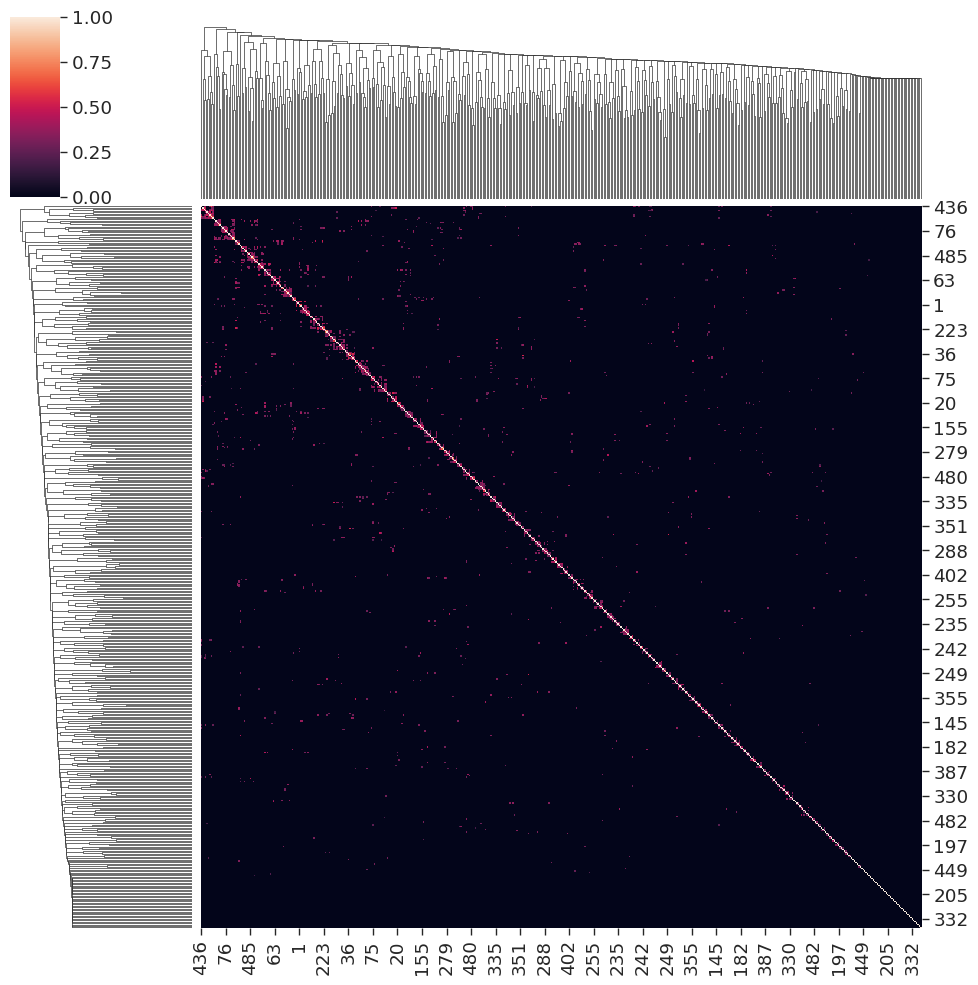

In [ ]:
sns.clustermap(M.toarray()[:500,:500])

In [ ]:
import sys
sys.getsizeof(M)

48

In [ ]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_glue
Computing diffusion components from X_glue for waypoint initialization ... 
Determing nearest neighbor graph...
Done.
Sampling waypoints ...
Done.
Selecting 1644 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:04<00:00, 10.48it/s]

Selecting 34 cells from greedy initialization.


In [ ]:
model.fit(min_iter=10, max_iter=200)

Randomly initialized A matrix.
Setting convergence threshold at 0.00512
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Starting iteration 30.
Completed iteration 30.
Starting iteration 40.
Completed iteration 40.
Converged after 40 iterations.


# Accessing results

## Model Convergence

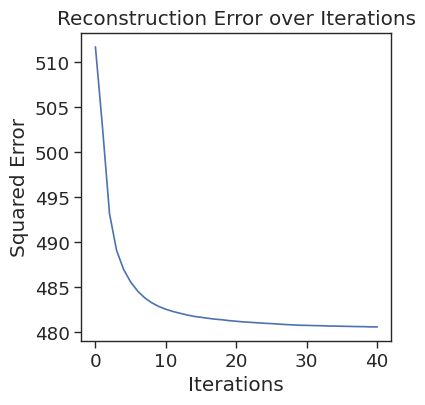

In [ ]:
# Check for convergence 
model.plot_convergence()

## SEACell Hard Assignments

These can be accessed as folows:
- in the modified anndata object in `.obs['SEAell']` 
- from the model using `.get_hard_assignments()` 


In [ ]:
adata.obs[['SEACell']].head()

,SEACell
index,
multiome_P-6774_S-10146#CTCAGGATCTTGCTAT-1,SEACell-1274
multiome_P-6774_S-10146#GTAGCGCTCCACCCTG-1,SEACell-811
multiome_P-6774_S-10146#GGCAATCGTCCTCCAA-1,SEACell-824
multiome_P-6774_S-10146#CGGACCTAGGCCTAAT-1,SEACell-1344
multiome_P-6774_S-10146#CCACTTGGTTGCGGAT-1,SEACell-45


In [ ]:
model.get_hard_assignments().head()

,SEACell
index,
multiome_P-6774_S-10146#CTCAGGATCTTGCTAT-1,SEACell-1274
multiome_P-6774_S-10146#GTAGCGCTCCACCCTG-1,SEACell-811
multiome_P-6774_S-10146#GGCAATCGTCCTCCAA-1,SEACell-824
multiome_P-6774_S-10146#CGGACCTAGGCCTAAT-1,SEACell-1344
multiome_P-6774_S-10146#CCACTTGGTTGCGGAT-1,SEACell-45


## SEACell Soft Assignments

Archetypal analysis returns soft assignments of cells to SEACells. The full assignment matrix can be accessed as the parameter ```model.A_```. However, the majority of single-cells are assigned to no more than 4 archetypes with non-trivial weight, so we return the top 5 metacell assignments as well as the corresponding assignment weights in the function ```model.get_soft_assignments()```

/scratch/24229487/ipykernel_370640/2269664087.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)


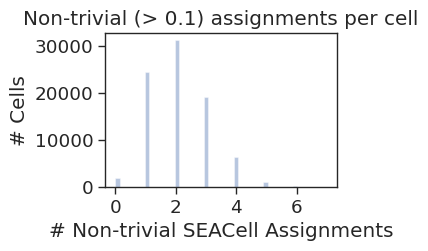

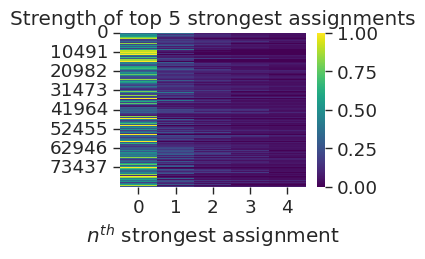

In [ ]:
plt.figure(figsize=(3,2))
sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)
plt.title(f'Non-trivial (> 0.1) assignments per cell')
plt.xlabel('# Non-trivial SEACell Assignments')
plt.ylabel('# Cells')
plt.show()

plt.figure(figsize=(3,2))
b = np.partition(model.A_.T, -5)    
sns.heatmap(np.sort(b[:,-5:])[:, ::-1], cmap='viridis', vmin=0)
plt.title('Strength of top 5 strongest assignments')
plt.xlabel('$n^{th}$ strongest assignment')
plt.show()


In [ ]:
labels,weights = model.get_soft_assignments()

In [ ]:
labels.head()

,0,1,2,3,4
index,,,,,
multiome_P-6774_S-10146#CTCAGGATCTTGCTAT-1,multiome_P-6774_S-10146#GGGAATATCACGCATG-1,multiome_P-6774_S-10146#TGAGCCGGTTCACCAT-1,multiome_P-6774_S-10146#CGCACACAGTTTCCTG-1,multiome_P-1764_S-1766#GAAGTGATCCCATAAA-1,atac_MUV86#GATGGCCCAGGTAGCA-1
multiome_P-6774_S-10146#GTAGCGCTCCACCCTG-1,multiome_P-6774_S-10146#ATAAGCCTCGTCCTTA-1,multiome_P-6774_S-10146#AAACGGATCGTACCGA-1,multiome_P-6774_S-10146#CTTAAGATCCTGGCTT-1,multiome_P-6774_S-10146#GGATACTTCTTGTTCG-1,atac_T20-90296#AGTCAACAGTCGAAAT-1
multiome_P-6774_S-10146#GGCAATCGTCCTCCAA-1,multiome_P-1764_S-1766#GAAGTGATCCCATAAA-1,multiome_P-6774_S-10146#TGAGCCGGTTCACCAT-1,atac_T20-90296#AGTCAACAGTCGAAAT-1,multiome_P-6774_S-10146#ATAAGCCTCGTCCTTA-1,GNG_region_11#TGAAACTGTTAACGGC-1
multiome_P-6774_S-10146#CGGACCTAGGCCTAAT-1,multiome_P-6774_S-10146#CTTAAGATCCTGGCTT-1,multiome_P-6774_S-10146#AAACGGATCGTACCGA-1,multiome_P-6774_S-10146#CGTACGGGTGCATTTC-1,multiome_P-6337_S-8821#AGGCAGGTCCGGTATG-1,atac_T20-90296#GTAGTACCAAATAGTG-1
multiome_P-6774_S-10146#CCACTTGGTTGCGGAT-1,GNG_region_11#TGAAACTGTTAACGGC-1,multiome_P-6774_S-10146#CAAACGCGTTGCACGG-1,GNG_region_11#TGCATCCTCTTAGCCC-1,atac_T20-90296#GCCAGCAGTCGTAATC-1,atac_T20-90296#AGTGTACCAAGCCTTA-1


# Summarizing data

- `core.summarize_by_SEACell()`

Datasets can be summarized by SEACell by aggregating cells within each SEACell, summing over all raw data for all cells belonging to a SEACell. The output of this function is an anndata object of shape n_metacells x original_data_dimension. Data is unnormalized and raw aggregated counts are stored in `X`. Attributes associated with variables (.var) are copied over, but relevant per SEACell attributes must be manually copied, since certain attributes may need to be summed, or averaged etc, depending on the attribute.

By default, `adata.raw` is used for summarization. Other layers present in the anndata can be specified using the parameter `summarize_layer` parameter

In [ ]:
print(adata.X)

  (0, 76)	2
  (0, 85)	2
  (0, 90)	2
  (0, 115)	2
  (0, 146)	1
  (0, 220)	1
  (0, 231)	2
  (0, 511)	2
  (0, 514)	1
  (0, 562)	2
  (0, 717)	2
  (0, 718)	2
  (0, 896)	1
  (0, 951)	2
  (0, 1015)	2
  (0, 1019)	3
  (0, 1027)	2
  (0, 1127)	2
  (0, 1163)	2
  (0, 1167)	2
  (0, 1194)	1
  (0, 1369)	1
  (0, 1416)	2
  (0, 1434)	2
  (0, 1449)	2
  :	:
  (83920, 374144)	2
  (83920, 374160)	2
  (83920, 374161)	2
  (83920, 374515)	2
  (83920, 374645)	2
  (83920, 374762)	1
  (83920, 375008)	2
  (83920, 375010)	2
  (83920, 375066)	2
  (83920, 375452)	2
  (83920, 375526)	2
  (83920, 375675)	1
  (83920, 375901)	2
  (83920, 376246)	2
  (83920, 376418)	2
  (83920, 376528)	2
  (83920, 376794)	2
  (83920, 377027)	1
  (83920, 377029)	2
  (83920, 377060)	2
  (83920, 377306)	2
  (83920, 377351)	2
  (83920, 377399)	1
  (83920, 377488)	2
  (83920, 377553)	2


In [ ]:
adata.X.data

array([2, 2, 2, ..., 1, 2, 2])

In [ ]:
adata.layers['counts'] = adata.X.copy()

In [ ]:
adata.write(os.path.join(data_dir, "archr_for_seacells_postrun.h5ad"), compression='gzip')

In [ ]:
SEACell_ad = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='counts')
SEACell_ad

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1678/1678 [01:44<00:00, 16.03it/s]


AnnData object with n_obs × n_vars = 1678 × 377577
    layers: 'raw'

In [ ]:
import gc
gc.collect()

6648

## Normalization

Normalization of metacell data can be performed using the `sc.pp.normalize_total` and `sc.pp.log1p` functions

# Evaluating Results

We provide several methods for evaluating SEACell assignments:

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/seacells/lib/python3.9/site-packages/SEACells-0.3.3-py3.9.egg/SEACells/plot.py:121: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby('SEACell').count().iloc[:, 0], bins=bins)


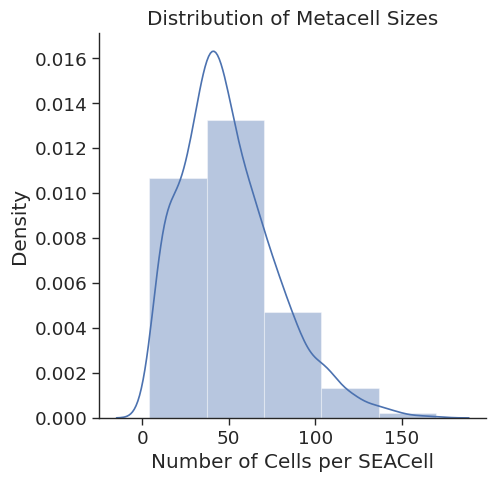

,size
SEACell,
SEACell-0,116
SEACell-1,123
SEACell-2,124
SEACell-3,109
SEACell-4,161
...,...
SEACell-1673,68
SEACell-1674,59
SEACell-1675,41


In [ ]:
SEACells.plot.plot_SEACell_sizes(adata, bins=5)

## Quantifying Results

SEACells also implements methods for visualizing the results of the SEACells algorithm 
    <ul> 
        <li>```.compute_celltype_purity(adata, col_name)``` computes the purity of different celltype labels within a SEACell metacell. Typically, col_name='celltype' or similar. Returns a pd.DataFrame of length n_SEACells.
        <li>```.compactness(adata, low_dim_embedding)``` computes the per-SEAcell variance in diffusion components. ```low_dim_embedding``` is a string specifying the low dimensional embedding with which diffusion components are calculated, typically 'X_pca' for RNA or 'X_svd' for ATAC. Lower values of compactness suggest more compact/lower variance metacells.
        <li>```separation(adata, low_dim_embedding,nth_nbr=1,cluster=None)``` computes the diffusion distance between a SEACell and its ```nth_nbr```. As before, ```low_dim_embedding``` is a string specifying the low dimensional embedding with which diffusion components are calculated, typically 'X_pca' for RNA or 'X_svd' for ATAC. If ```cluster``` is provided as a string, e.g. 'celltype', nearest neighbors are restricted to have the same celltype value.  Higher values of separation suggest better distinction between metacells.
    </ul>
    


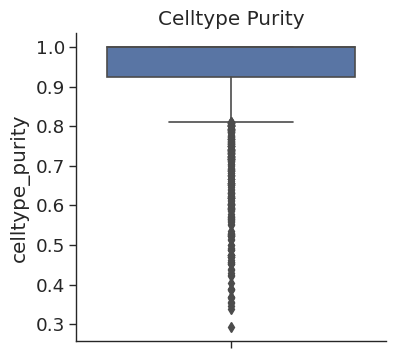

,celltype,celltype_purity
SEACell,,
SEACell-0,MP 7,1.000000
SEACell-1,MP 7,1.000000
SEACell-2,MP 11,0.927419
SEACell-3,MP 9,0.880734
SEACell-4,MP 2,1.000000


In [ ]:
SEACell_purity = SEACells.evaluate.compute_celltype_purity(adata, 'celltype')

plt.figure(figsize=(4,4))
sns.boxplot(data=SEACell_purity, y='celltype_purity')
plt.title('Celltype Purity')
sns.despine()
plt.show()
plt.close()

SEACell_purity.head()

Determing nearest neighbor graph...


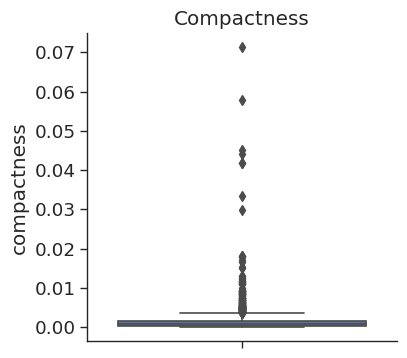

,compactness
SEACell,
SEACell-0,0.000585
SEACell-1,0.000248
SEACell-2,0.000514
SEACell-3,0.003810
SEACell-4,0.000397


In [ ]:
compactness = SEACells.evaluate.compactness(adata, 'X_glue')

plt.figure(figsize=(4,4))
sns.boxplot(data=compactness, y='compactness')
plt.title('Compactness')
sns.despine()
plt.show()
plt.close()

compactness.head()

Determing nearest neighbor graph...


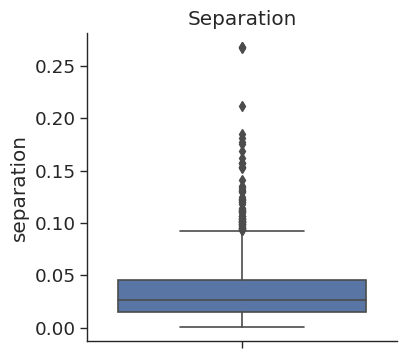

,separation
SEACell,
SEACell-0,0.010588
SEACell-1,0.001600
SEACell-2,0.034663
SEACell-3,0.060622
SEACell-4,0.017963


In [ ]:
separation = SEACells.evaluate.separation(adata, 'X_glue',nth_nbr=1)

plt.figure(figsize=(4,4))
sns.boxplot(data=separation, y='separation')
plt.title('Separation')
sns.despine()
plt.show()
plt.close()

separation.head()